# E-Waste Image Classification — Custom CNN vs InceptionV3 vs ResNet152

**Goal:** classify e-waste images into their categories, then compare a *custom-built CNN* against two *transfer-learning* backbones (InceptionV3, ResNet152).

**How to read this notebook (interview framing):**
Every section starts with a short **"Why"** note. In an interview you are rarely asked *"what did you do"* — you are asked *"why did you do it that way and what was the alternative"*. The Why-notes are your script.

**Pipeline:**
1. Explore the data (class balance, sample images) — *never trust a dataset you haven't looked at.*
2. Build one reusable input pipeline (`tf.data`) with per-model preprocessing + augmentation.
3. Train a custom CNN from scratch → baseline.
4. Two-phase transfer learning with InceptionV3.
5. Two-phase transfer learning with ResNet152.
6. Compare all three on the **same held-out test set** with the **same metrics**.
7. Grad-CAM to check the models look at sensible pixels (interpretability).

## 1. Setup & configuration

**Why fix a seed?** Reproducibility. If an interviewer re-runs your notebook and gets different numbers, your comparison is not trustworthy. A fixed seed makes the run repeatable.

**Why 224×224 for *all* models?** InceptionV3's native size is 299 and ResNet's is 224, but forcing every model to the *same* input size means the only thing changing between experiments is the architecture — that makes the comparison fair. It also keeps memory predictable.

In [2]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Locate the dataset

The Kaggle mount path can vary (`/kaggle/input/e-waste-image-dataset`, a nested folder, etc.), and the dataset may or may not ship with pre-made `train/val/test` folders. Instead of hard-coding a path and hoping, we **auto-detect** the structure. This is defensive engineering — the code adapts instead of breaking.

Two layouts are handled:
- **Layout A** — already split: a folder containing `train/`, `val` (or `validation`), `test/`.
- **Layout B** — just class folders: we make an 80/10/10 split ourselves (stratified by folder).

In [3]:
def find_dataset_root(search_roots):
    """Walk the input dirs and return (mode, path_info).
    mode == 'split'  -> path_info = dict(train=..., val=..., test=...)
    mode == 'flat'   -> path_info = path that directly contains class folders
    """
    val_names  = {"val", "valid", "validation"}
    def subdirs(p):
        return [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))]

    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for cur, dirs, _ in os.walk(root):
            dl = {d.lower() for d in dirs}
            # Layout A: pre-split
            if "train" in dl and "test" in dl:
                train = os.path.join(cur, [d for d in dirs if d.lower()=="train"][0])
                test  = os.path.join(cur, [d for d in dirs if d.lower()=="test"][0])
                valm  = [d for d in dirs if d.lower() in val_names]
                val   = os.path.join(cur, valm[0]) if valm else None
                return "split", dict(train=train, val=val, test=test)

    # Layout B: find a folder whose subdirs look like classes (>=3 folders, each with images)
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for cur, dirs, _ in os.walk(root):
            if len(dirs) >= 3:
                sample = os.path.join(cur, dirs[0])
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
                if imgs:
                    return "flat", cur
    raise FileNotFoundError("Could not locate the dataset. Check the /kaggle/input path.")

SEARCH_ROOTS = [
    "/kaggle/input",
    "/kaggle/input/e-waste-image-dataset",
    "/kaggle/input/datasets/akshat103/e-waste-image-dataset",
]
mode, info = find_dataset_root(SEARCH_ROOTS)
print("Detected layout:", mode)
print(info)

Detected layout: split
{'train': '/kaggle/input/datasets/akshat103/e-waste-image-dataset/modified-dataset/train', 'val': '/kaggle/input/datasets/akshat103/e-waste-image-dataset/modified-dataset/val', 'test': '/kaggle/input/datasets/akshat103/e-waste-image-dataset/modified-dataset/test'}


## 3. Build the raw datasets

**Why `image_dataset_from_directory` (tf.data) instead of the old `ImageDataGenerator`?**
`ImageDataGenerator` is legacy and does augmentation on the CPU, which starves the GPU. `tf.data` pipelines are the modern standard: they cache, prefetch, and run on multiple cores, so the GPU never waits. Mentioning this in an interview signals you know current best practice.

We load labels as integers (`label_mode='int'`) and pair them with `SparseCategoricalCrossentropy` — cleaner than one-hot and it makes building the confusion matrix trivial.

In [4]:
def load_raw(mode, info, img_size, batch_size, seed):
    if mode == "split":
        train = keras.utils.image_dataset_from_directory(
            info["train"], image_size=img_size, batch_size=batch_size,
            label_mode="int", shuffle=True, seed=seed)
        if info["val"]:
            val = keras.utils.image_dataset_from_directory(
                info["val"], image_size=img_size, batch_size=batch_size,
                label_mode="int", shuffle=False)
        else:  # carve a val set out of train if none provided
            val = keras.utils.image_dataset_from_directory(
                info["train"], image_size=img_size, batch_size=batch_size,
                label_mode="int", shuffle=True, seed=seed,
                validation_split=0.15, subset="validation")
        test = keras.utils.image_dataset_from_directory(
            info["test"], image_size=img_size, batch_size=batch_size,
            label_mode="int", shuffle=False)
    else:  # flat -> make an 80/10/10 split
        full = info
        train = keras.utils.image_dataset_from_directory(
            full, image_size=img_size, batch_size=batch_size, label_mode="int",
            shuffle=True, seed=seed, validation_split=0.2, subset="training")
        rest = keras.utils.image_dataset_from_directory(
            full, image_size=img_size, batch_size=batch_size, label_mode="int",
            shuffle=True, seed=seed, validation_split=0.2, subset="validation")
        # split the 20% "rest" evenly into val/test
        rest_batches = tf.data.experimental.cardinality(rest).numpy()
        val  = rest.take(rest_batches // 2)
        test = rest.skip(rest_batches // 2)
    return train, val, test

raw_train, raw_val, raw_test = load_raw(mode, info, IMG_SIZE, BATCH_SIZE, SEED)
CLASS_NAMES = raw_train.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)

Found 2400 files belonging to 10 classes.


I0000 00:00:1786092334.356539      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786092334.359399      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Num classes: 10


## 4. Explore: class balance & sample images

**Why look at class balance first?** If one class has 10× the images of another, plain accuracy becomes misleading (a model can score high by ignoring rare classes). Knowing the balance up front tells us whether we need **class weights** and whether **accuracy alone** is an honest metric.

Battery            240
Keyboard           240
Microwave          240
Mobile             240
Mouse              240
PCB                240
Player             240
Printer            240
Television         240
Washing Machine    240
dtype: int64


/tmp/ipykernel_58/425031078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.values, y=dist.index, palette="viridis")


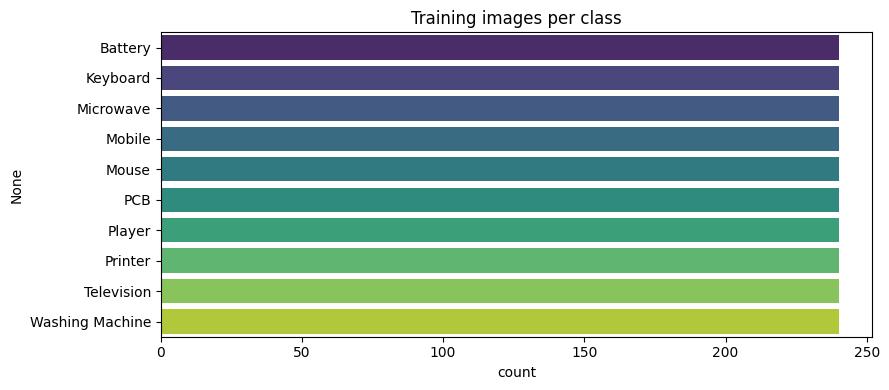


Imbalance ratio (max/min): 1.00
-> If this is well above ~2, we will use class weights during training.


In [5]:
# Count images per class from the training set
counts = {c: 0 for c in CLASS_NAMES}
for _, labels in raw_train.unbatch().batch(256):
    for l in labels.numpy():
        counts[CLASS_NAMES[l]] += 1

dist = pd.Series(counts).sort_values(ascending=False)
print(dist)

plt.figure(figsize=(9,4))
sns.barplot(x=dist.values, y=dist.index, palette="viridis")
plt.title("Training images per class"); plt.xlabel("count"); plt.tight_layout(); plt.show()

imbalance = dist.max() / max(dist.min(), 1)
print(f"\nImbalance ratio (max/min): {imbalance:.2f}")
print("-> If this is well above ~2, we will use class weights during training.")

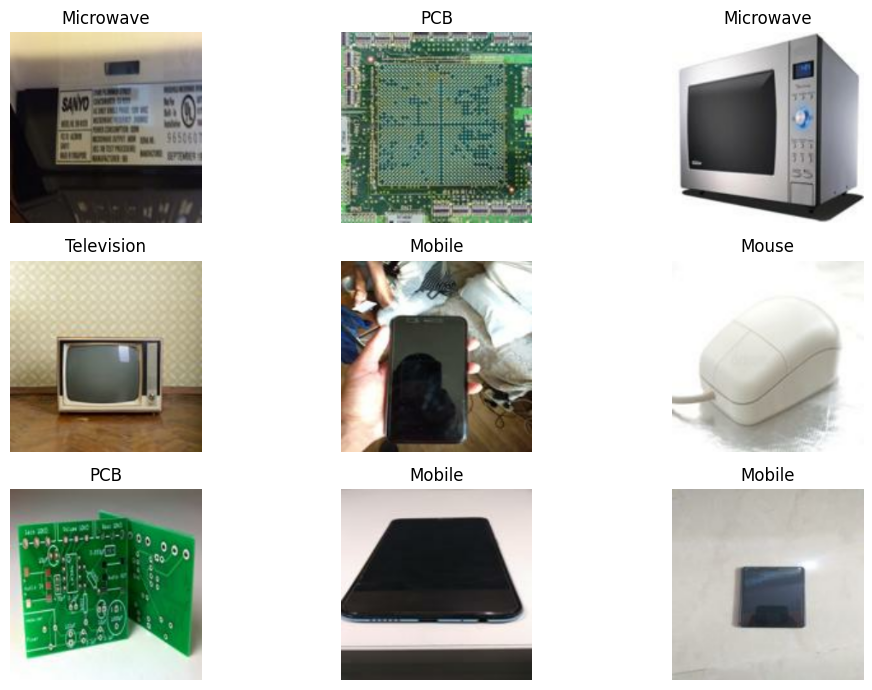

In [6]:
# Peek at a few images so we know what the model actually sees
plt.figure(figsize=(11,7))
for imgs, labels in raw_train.take(1):
    for i in range(min(9, imgs.shape[0])):
        plt.subplot(3,3,i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]]); plt.axis("off")
plt.tight_layout(); plt.show()

## 5. Class weights (handle imbalance)

**Why class weights and not oversampling?** Oversampling duplicates rare images and can overfit them. Class weights instead tell the loss function *"a mistake on a rare class costs more"* — it fixes the imbalance without touching the data. We compute inverse-frequency weights.

In [7]:
total = sum(counts.values())
class_weight = {i: total / (NUM_CLASSES * counts[c]) for i, c in enumerate(CLASS_NAMES)}
print("class_weight:", {k: round(v,3) for k,v in class_weight.items()})

class_weight: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


## 6. One reusable input pipeline per model

**Why per-model preprocessing?** Each backbone was pretrained expecting a *specific* input scaling:
- Custom CNN → we just scale pixels to `[0,1]`.
- InceptionV3 → `preprocess_input` maps to `[-1, 1]`.
- ResNet152 → `preprocess_input` does Caffe-style mean subtraction on BGR.

Feeding the wrong scaling to a pretrained network quietly wrecks accuracy — a classic silent bug. So the preprocessing function is a *parameter* of the pipeline, and each model gets the right one.

**Why augment only the training set?** Augmentation (flips, small rotations/zooms) synthetically enlarges the training data and teaches invariance, which fights overfitting on a small dataset. But val/test must stay untouched — otherwise you're measuring performance on distorted images, not real ones.

We keep augmentation as **in-model Keras layers** so it's automatically switched *off* at inference time. Preprocessing (scaling) goes in the `tf.data` pipeline.

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def make_pipeline(preprocess_fn):
    """Return (train, val, test) datasets with the given preprocessing applied."""
    def prep(ds, training):
        ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=AUTOTUNE)
        if training:
            ds = ds.shuffle(1000, seed=SEED)
        return ds.cache().prefetch(AUTOTUNE)
    return (prep(raw_train, True), prep(raw_val, False), prep(raw_test, False))

# Preprocessing functions for each model
prep_custom    = lambda x: x / 255.0
prep_inception = keras.applications.inception_v3.preprocess_input
prep_resnet    = keras.applications.resnet.preprocess_input

## 7. Shared training helpers

**Why these three callbacks?**
- **EarlyStopping** — stop when validation loss stops improving, and restore the best weights. Prevents overfitting and saves compute.
- **ReduceLROnPlateau** — when progress stalls, cut the learning rate so the optimizer can settle into a better minimum instead of bouncing around.
- **ModelCheckpoint** — always keep the best-performing weights on disk, not just the last epoch's.

**Why evaluate with a report + confusion matrix, not just accuracy?** Accuracy hides *which* classes fail. Precision/recall/F1 per class + a confusion matrix show exactly where the model confuses categories (e.g. mouse vs keyboard) — that's the analysis an interviewer wants to see.

In [9]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6),
        ModelCheckpoint(f"best_{name}.keras", monitor="val_accuracy", save_best_only=True),
    ]

def plot_history(hist, title):
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(f"{title} — accuracy"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(f"{title} — loss"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

def evaluate(model, test_ds, title):
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    acc = (y_true == y_pred).mean()
    print(f"\n===== {title} — test accuracy: {acc:.4f} =====")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{title} — confusion matrix"); plt.ylabel("true"); plt.xlabel("pred")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
    return acc

## 8. Model 1 — Custom CNN (the baseline)

**Why build a custom CNN at all if transfer learning usually wins?** It's the *baseline*. Without it you can't quantify how much the pretrained models actually buy you. It also proves you understand what's inside a CNN, not just how to call `applications.ResNet152`.

**Architecture choices, defended:**
- **Stacked 3×3 conv blocks, filters 32→64→128→256.** Widening as we go deep is standard: early layers capture edges/textures (few filters needed), deeper layers capture complex parts (more filters). Two 3×3 convs stacked see the same region as one 5×5 but with fewer parameters and more non-linearity.
- **BatchNormalization after every conv.** Stabilises and speeds up training, and adds mild regularisation. Lets us use a higher learning rate safely.
- **GlobalAveragePooling instead of Flatten+Dense.** Flatten creates a huge parameter count that overfits small datasets; GAP collapses each feature map to one number — far fewer parameters, better generalisation.
- **Dropout (0.4 / 0.3).** Regularisation — randomly drops activations so the network can't over-rely on any single feature.
- **Kept relatively shallow (4 blocks).** The dataset is small; a very deep from-scratch net would overfit. Depth is a knob we tune to data size.

In [16]:
def build_custom_cnn(num_classes):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    for f in [32, 64, 128, 256]:
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

tr_c, va_c, te_c = make_pipeline(prep_custom)
custom = build_custom_cnn(NUM_CLASSES)
custom.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
custom.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_97          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,245,482 (4.75 MB)

 Trainable params: 1,243,050 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 297ms/step - accuracy: 0.2717 - loss: 2.3165 - val_accuracy: 0.1000 - val_loss: 2.7811 - learning_rate: 0.0010
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - accuracy: 0.3479 - loss: 1.9552 - val_accuracy: 0.1000 - val_loss: 3.4984 - learning_rate: 0.0010
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 270ms/step - accuracy: 0.3908 - loss: 1.7725 - val_accuracy: 0.1000 - val_loss: 3.0861 - learning_rate: 0.0010
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.4313 - loss: 1.6218 - val_accuracy: 0.1367 - val_loss: 3.5737 - learning_rate: 0.0010
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - accuracy: 0.5013 - loss: 1.3876 - val_accuracy: 0.1100 - val_loss: 2.9035 - learning_rate: 3.0000e-04
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 275ms/step - accuracy: 0.5279 - loss: 1.2964 - val_accuracy: 0.1567 - val_loss: 2.4564 - learning_rate: 3.0000e-04
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.5479 - 

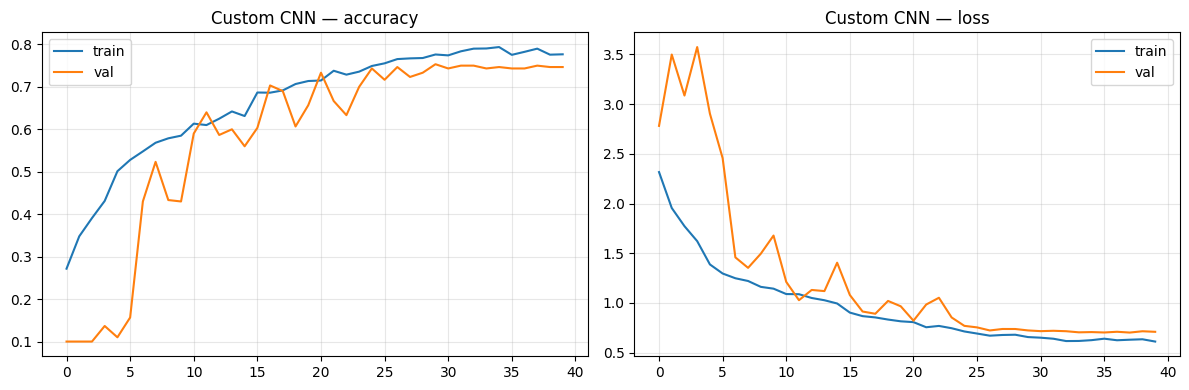


===== Custom CNN — test accuracy: 0.6933 =====
                 precision    recall  f1-score   support

        Battery      0.526     0.667     0.588        30
       Keyboard      1.000     0.933     0.966        30
      Microwave      0.783     0.600     0.679        30
         Mobile      0.759     0.733     0.746        30
          Mouse      0.586     0.567     0.576        30
            PCB      0.852     0.767     0.807        30
         Player      0.394     0.433     0.413        30
        Printer      0.630     0.567     0.596        30
     Television      0.710     0.733     0.721        30
Washing Machine      0.800     0.933     0.862        30

       accuracy                          0.693       300
      macro avg      0.704     0.693     0.695       300
   weighted avg      0.704     0.693     0.695       300



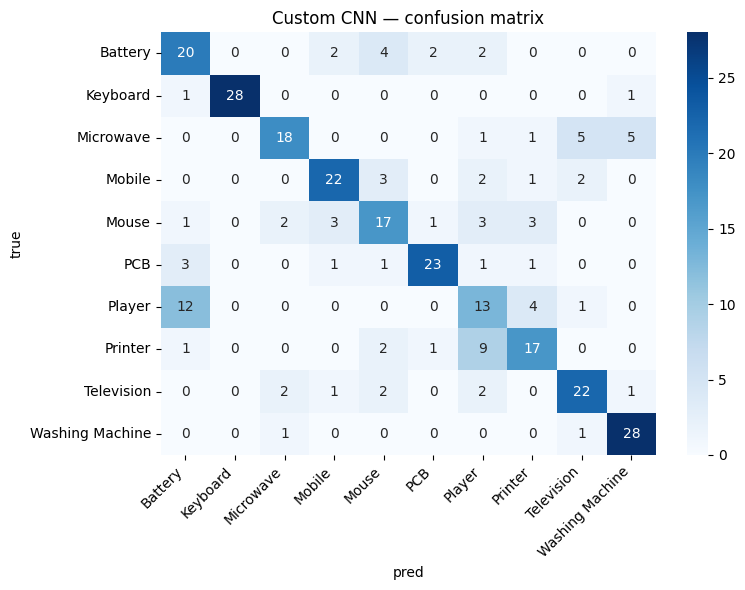

In [17]:
hist_custom = custom.fit(
    tr_c, validation_data=va_c, epochs=40,
    class_weight=class_weight, callbacks=get_callbacks("custom"))
plot_history(hist_custom, "Custom CNN")
acc_custom = evaluate(custom, te_c, "Custom CNN")

## 9. Transfer-learning helpers (two-phase fine-tuning)

**Why transfer learning?** ImageNet-pretrained backbones already know generic vision features (edges, shapes, textures). We reuse those and only learn the e-waste-specific part — this needs far less data and reaches higher accuracy than training from scratch.

**Why two phases?**
1. **Phase 1 — freeze the backbone, train only the new head.** The head starts random; if we let gradients flow into the backbone immediately, those large random gradients would corrupt the good pretrained weights. So we freeze first and let the head "catch up".
2. **Phase 2 — unfreeze the top of the backbone, train with a *tiny* learning rate (1e-5).** Now we gently adapt the high-level features to e-waste. Low LR = we nudge, not overwrite.

**Why keep BatchNorm layers frozen during fine-tuning?** BN layers hold running mean/variance from ImageNet. Unfreezing them on a small batch would let those statistics drift and destabilise training — a subtle but important detail that impresses interviewers.

In [10]:
def build_transfer(backbone_fn, num_classes, name):
    base = backbone_fn(include_top=False, weights="imagenet",
                       input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=name), base

def train_two_phase(model, base, tr, va, name, unfreeze_frac=0.30,
                    epochs_head=12, epochs_ft=15):
    # ---- Phase 1: train head only ----
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print(f"\n[{name}] Phase 1 — head only")
    h1 = model.fit(tr, validation_data=va, epochs=epochs_head,
                   class_weight=class_weight, callbacks=get_callbacks(name+"_p1"))

    # ---- Phase 2: unfreeze top layers, keep BN frozen ----
    base.trainable = True
    n = len(base.layers)
    cutoff = int(n * (1 - unfreeze_frac))
    for i, layer in enumerate(base.layers):
        if i < cutoff or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True
    trainable = sum(l.trainable for l in base.layers)
    print(f"[{name}] Phase 2 — fine-tuning {trainable}/{n} backbone layers (BN kept frozen)")
    model.compile(optimizer=keras.optimizers.Adam(1e-5),  # tiny LR
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(tr, validation_data=va, epochs=epochs_ft,
                   class_weight=class_weight, callbacks=get_callbacks(name+"_p2"))
    return h1, h2

## 10. Model 2 — InceptionV3

**Why InceptionV3 specifically?** Its inception modules run several filter sizes (1×1, 3×3, 5×5) *in parallel* and concatenate them, so each layer captures features at multiple scales at once — useful when objects appear at different sizes/framings, exactly the case for photographed e-waste. It also factorises big convolutions (e.g. 5×5 → two 3×3, n×n → 1×n + n×1), giving strong accuracy at a **lower compute/parameter cost** than a similarly deep plain net. It's the efficiency-minded choice.

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

[inceptionv3] Phase 1 — head only
Epoch 1/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.4121 - loss: 1.8146 - val_accuracy: 0.7800 - val_loss: 0.6963 - learning_rate: 0.0010
Epoch 2/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.6450 - loss: 1.0587 - val_accuracy: 0.8100 - val_loss: 0.5650 - learning_rate: 0.0010
Epoch 3/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.7067 - loss: 0.8938 - val_accuracy: 0.8767 - val_loss: 0.4469 - learning_rate: 0.0010
Epoch 4/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.7412 - loss: 0.7957 - val_accuracy: 0.8900 - val_loss: 0.4076 - learning_rate: 0.0010
Epoch 5/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7575 - loss: 0.7419 - val_accuracy: 0.8933 - val_loss: 0.3610 - learning_rate: 0.0010
Epoch 6/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.7758 - loss: 0.6879 - val_accuracy: 0.8800 - val_loss: 0.3857 - learning_rate: 0.0010
Ep

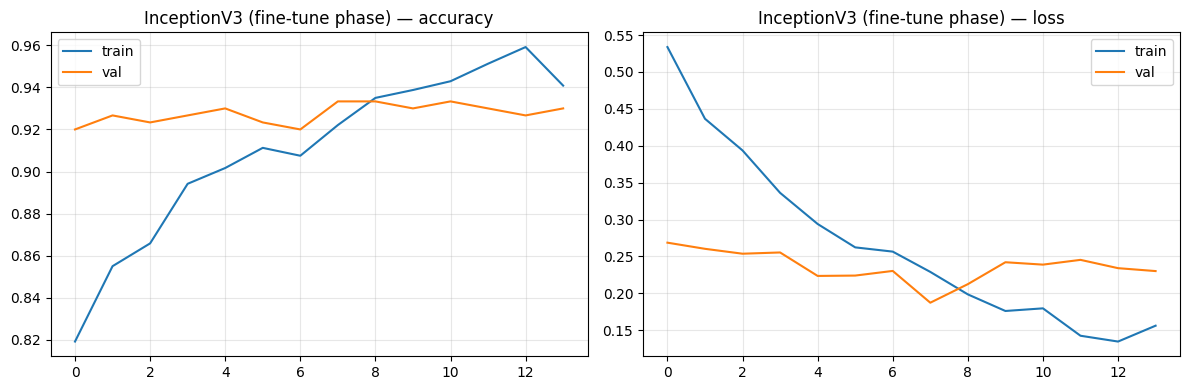


===== InceptionV3 — test accuracy: 0.9367 =====
                 precision    recall  f1-score   support

        Battery      0.920     0.767     0.836        30
       Keyboard      0.968     1.000     0.984        30
      Microwave      0.882     1.000     0.938        30
         Mobile      1.000     0.900     0.947        30
          Mouse      0.967     0.967     0.967        30
            PCB      0.929     0.867     0.897        30
         Player      0.906     0.967     0.935        30
        Printer      0.909     1.000     0.952        30
     Television      1.000     0.900     0.947        30
Washing Machine      0.909     1.000     0.952        30

       accuracy                          0.937       300
      macro avg      0.939     0.937     0.936       300
   weighted avg      0.939     0.937     0.936       300



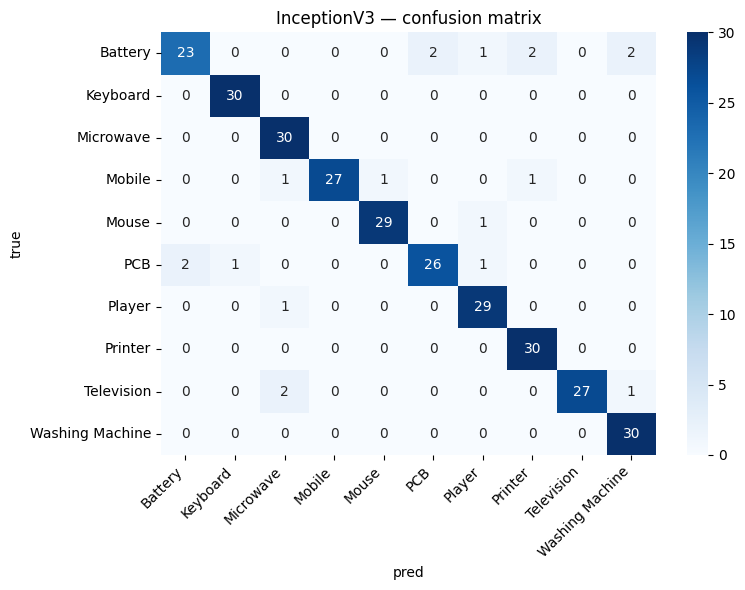

In [11]:
tr_i, va_i, te_i = make_pipeline(prep_inception)
inception, base_i = build_transfer(keras.applications.InceptionV3, NUM_CLASSES, "inceptionv3")
hi1, hi2 = train_two_phase(inception, base_i, tr_i, va_i, "inceptionv3")
plot_history(hi2, "InceptionV3 (fine-tune phase)")
acc_incep = evaluate(inception, te_i, "InceptionV3")

## 11. Model 3 — ResNet152

**Why ResNet152?** It's the *depth/capacity* contrast to Inception's *efficiency*. Its **residual (skip) connections** let gradients flow straight through, which is what makes training a 152-layer network possible at all (they solve the vanishing-gradient problem). More depth = a richer feature hierarchy and often higher ceiling accuracy — but at higher memory and inference cost. Putting Inception and ResNet152 side by side lets us discuss the classic **accuracy-vs-cost trade-off**, which is a great interview talking point.

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

[resnet152] Phase 1 — head only
Epoch 1/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 480ms/step - accuracy: 0.5046 - loss: 1.5234 - val_accuracy: 0.7867 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 2/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 382ms/step - accuracy: 0.7450 - loss: 0.7730 - val_accuracy: 0.8967 - val_loss: 0.3417 - learning_rate: 0.0010
Epoch 3/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 376ms/step - accuracy: 0.7763 - loss: 0.6506 - val_accuracy: 0.9067 - val_loss: 0.3046 - learning_rate: 0.0010
Epoch 4/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 349ms/step - accuracy: 0.8175 - loss: 0.5354 - val_accuracy: 0.8967 - val_loss: 0.2815 - learning_rate: 0.0010
Epoch 5/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - accuracy: 0.8263 - loss: 0.4878 - val_accuracy: 0.9033 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 6/12
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 348ms/step - accuracy: 0.8496 - loss: 0.4611 - val_accuracy: 0.9067 - val_loss: 0.2346 - learning_rate: 0.0

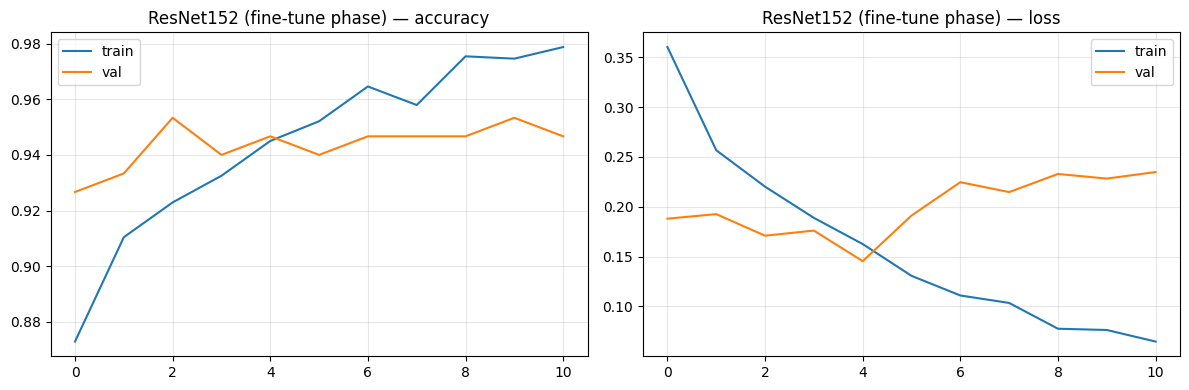


===== ResNet152 — test accuracy: 0.9500 =====
                 precision    recall  f1-score   support

        Battery      0.962     0.833     0.893        30
       Keyboard      0.968     1.000     0.984        30
      Microwave      0.968     1.000     0.984        30
         Mobile      1.000     0.967     0.983        30
          Mouse      0.967     0.967     0.967        30
            PCB      0.935     0.967     0.951        30
         Player      0.897     0.867     0.881        30
        Printer      0.906     0.967     0.935        30
     Television      1.000     0.933     0.966        30
Washing Machine      0.909     1.000     0.952        30

       accuracy                          0.950       300
      macro avg      0.951     0.950     0.950       300
   weighted avg      0.951     0.950     0.950       300



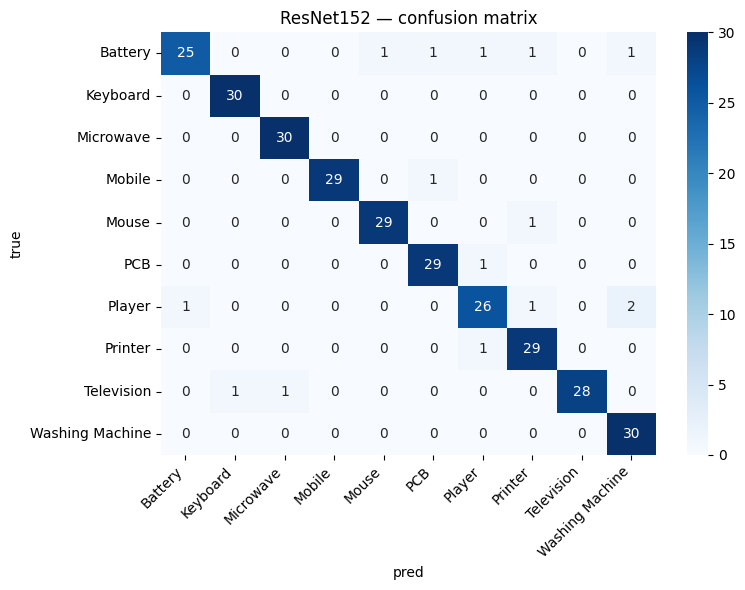

In [12]:
tr_r, va_r, te_r = make_pipeline(prep_resnet)
resnet, base_r = build_transfer(keras.applications.ResNet152, NUM_CLASSES, "resnet152")
hr1, hr2 = train_two_phase(resnet, base_r, tr_r, va_r, "resnet152")
plot_history(hr2, "ResNet152 (fine-tune phase)")
acc_resnet = evaluate(resnet, te_r, "ResNet152")

## 12. Head-to-head comparison

**Why compare on parameters *and* accuracy?** The "best" model in an interview is rarely just the most accurate — it's the best trade-off for the deployment target. A model that's 1% more accurate but 5× larger may be the *wrong* pick for a phone or an edge device. Show that you think about this.

         model  test_acc  params_M
0    ResNet152     0.950    58.391
1  InceptionV3     0.937    21.823
2   Custom CNN     0.693     1.245


/tmp/ipykernel_58/1055903350.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="model", y="test_acc", ax=ax[0], palette="crest")
/tmp/ipykernel_58/1055903350.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="model", y="params_M", ax=ax[1], palette="flare")


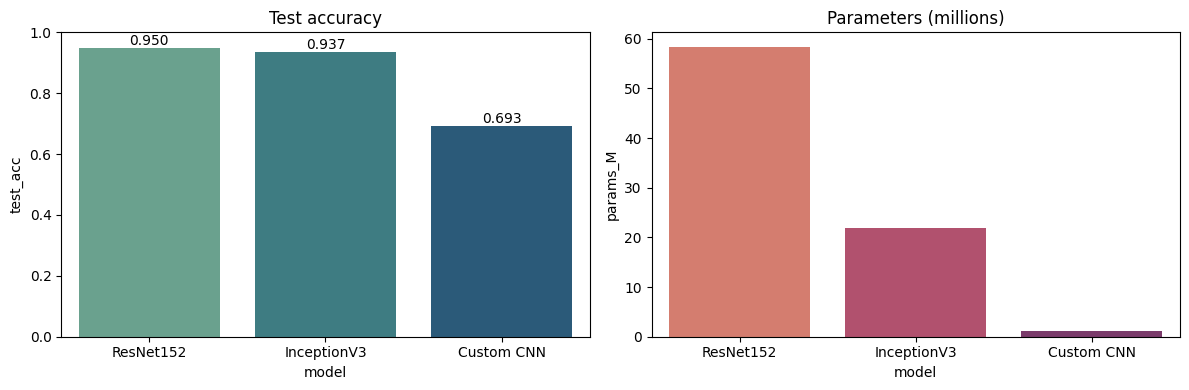


Highest accuracy: ResNet152 (0.950).
But state your pick as accuracy-per-parameter for the target device, not raw accuracy alone.


In [18]:
def param_count(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights) +
               sum(np.prod(w.shape) for w in m.non_trainable_weights))

summary = pd.DataFrame({
    "model":     ["Custom CNN", "InceptionV3", "ResNet152"],
    "test_acc":  [acc_custom, acc_incep, acc_resnet],
    "params_M":  [param_count(custom)/1e6, param_count(inception)/1e6, param_count(resnet)/1e6],
}).sort_values("test_acc", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(summary)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=summary, x="model", y="test_acc", ax=ax[0], palette="crest")
ax[0].set_title("Test accuracy"); ax[0].set_ylim(0,1)
for i,v in enumerate(summary.test_acc): ax[0].text(i, v+0.01, f"{v:.3f}", ha="center")
sns.barplot(data=summary, x="model", y="params_M", ax=ax[1], palette="flare")
ax[1].set_title("Parameters (millions)")
plt.tight_layout(); plt.show()

best = summary.iloc[0]
print(f"\nHighest accuracy: {best.model} ({best.test_acc:.3f}).")
print("But state your pick as accuracy-per-parameter for the target device, "
      "not raw accuracy alone.")

## 13. Grad-CAM — is the model looking at the right pixels?

**Why bother?** High accuracy can hide a cheating model that keys on a background artefact instead of the object. Grad-CAM produces a heatmap of the pixels driving each prediction. If the heat lands on the actual device, the model learned real features; if it's on the corner of the image, be suspicious. This "does it look where a human would look" check is a strong, memorable thing to show.

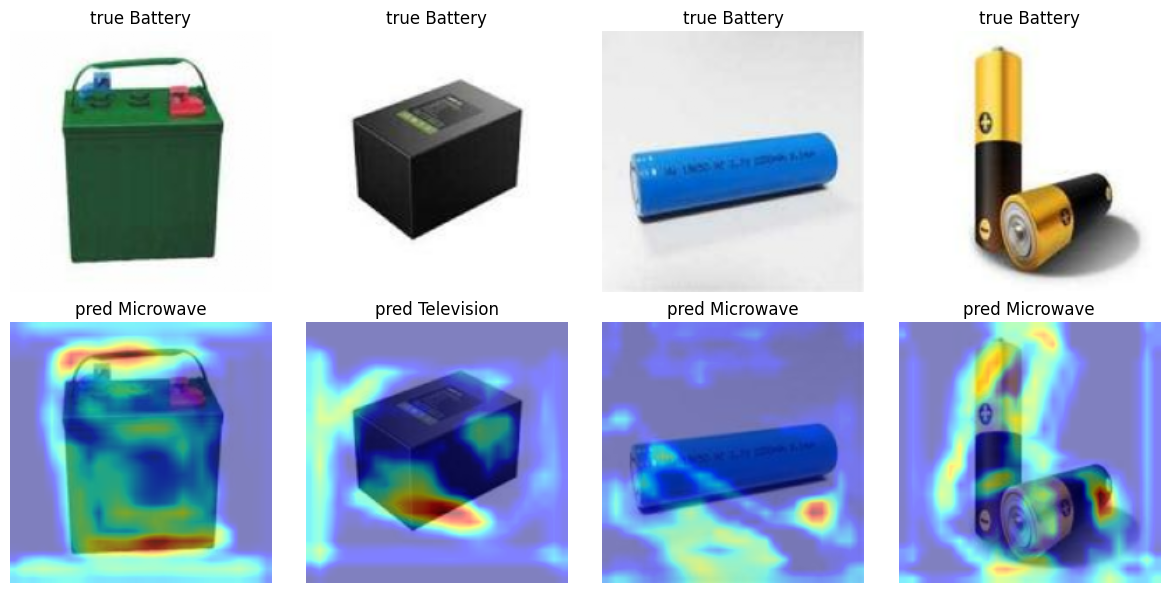

In [19]:
def make_gradcam(model, img_array, last_conv_name=None):
    # find last conv layer if not given
    if last_conv_name is None:
        for l in reversed(model.layers):
            if isinstance(l, keras.layers.Conv2D):
                last_conv_name = l.name; break
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        cls = tf.argmax(preds[0])
        loss = preds[:, cls]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heat = conv_out @ pooled[..., None]
    heat = tf.squeeze(heat)
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    return heat.numpy(), int(cls)

# Grad-CAM works most cleanly on the custom CNN (conv layers are top-level).
for imgs, labels in te_c.take(1):
    plt.figure(figsize=(12,6))
    for i in range(min(4, imgs.shape[0])):
        arr = imgs[i:i+1]
        heat, cls = make_gradcam(custom, arr)
        heat = tf.image.resize(heat[..., None], IMG_SIZE).numpy().squeeze()
        plt.subplot(2,4,i+1); plt.imshow(imgs[i].numpy()); plt.axis("off")
        plt.title(f"true {CLASS_NAMES[labels[i]]}")
        plt.subplot(2,4,i+5); plt.imshow(imgs[i].numpy())
        plt.imshow(heat, cmap="jet", alpha=0.5); plt.axis("off")
        plt.title(f"pred {CLASS_NAMES[cls]}")
    plt.tight_layout(); plt.show()

## 14. Interview defence — one-line answers to expect

- **Why a custom CNN if pretrained wins?** It's the baseline that quantifies transfer-learning's gain and proves I understand the internals.
- **Why 3×3 convs?** Same receptive field as larger kernels, fewer params, more non-linearity.
- **Why GlobalAveragePooling over Flatten?** Cuts parameters massively → less overfitting on a small dataset.
- **Why BatchNorm + Dropout together?** BN stabilises/speeds training; Dropout regularises. They target different problems.
- **Why freeze then fine-tune?** A random head would push huge gradients into the pretrained backbone and corrupt it; freeze-first prevents that.
- **Why LR 1e-5 in phase 2?** Nudge pretrained weights, don't overwrite them.
- **Why keep BN frozen while fine-tuning?** Small batches would corrupt the ImageNet running statistics.
- **Why InceptionV3 vs ResNet152?** Inception = multi-scale, efficient; ResNet152 = very deep, residual connections, higher ceiling but heavier. Chosen to contrast efficiency vs capacity.
- **Why class weights not oversampling?** Fixes imbalance in the loss without duplicating/overfitting rare images.
- **Why F1 + confusion matrix, not just accuracy?** Accuracy hides per-class failure and lies under imbalance.
- **Why augment only train?** Augmentation teaches invariance; val/test must reflect real, undistorted data.
- **Which model would you ship?** Whichever gives the best accuracy-per-cost for the target hardware — not necessarily the most accurate.
- **Biggest risk?** Overfitting on a small dataset → mitigated by augmentation, dropout, GAP, early stopping, transfer learning.

In [20]:
import time
def latency_ms(model, ds, warmup=5, iters=50):
    for x, _ in ds.take(1): sample = x[:1]
    for _ in range(warmup): _ = model(sample, training=False).numpy()
    ts = []
    for _ in range(iters):
        t = time.perf_counter(); _ = model(sample, training=False).numpy()
        ts.append((time.perf_counter() - t) * 1000)
    return float(np.mean(ts)), float(np.std(ts))

for name, m, ds in [("Custom CNN", custom, te_c),
                    ("InceptionV3", inception, te_i),
                    ("ResNet152", resnet, te_r)]:
    mean, std = latency_ms(m, ds)
    print(f"{name:12s}: {mean:6.2f} ± {std:4.2f} ms/image")

Custom CNN  :  32.14 ± 0.68 ms/image
InceptionV3 : 286.83 ± 6.99 ms/image
ResNet152   : 615.85 ± 10.91 ms/image


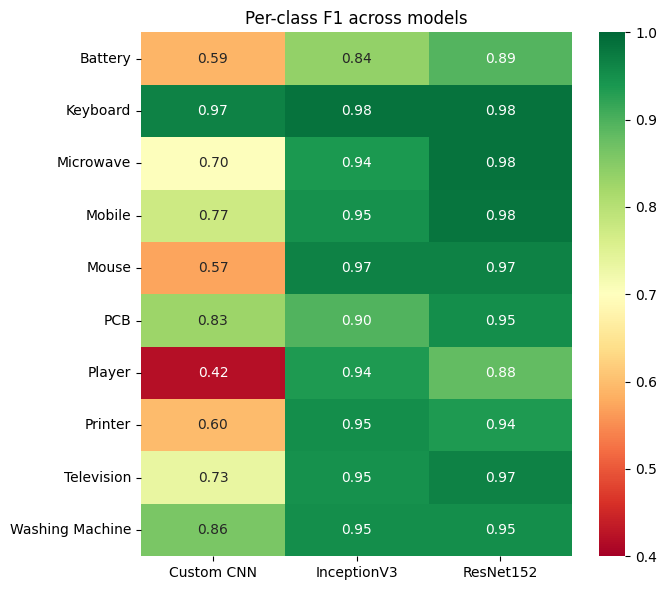

In [21]:
from sklearn.metrics import f1_score
def y_true_pred(model, ds):
    yt = np.concatenate([y.numpy() for _, y in ds])
    yp = model.predict(ds, verbose=0).argmax(1)
    return yt, yp

f1_tbl = {}
for name, m, ds in [("Custom CNN", custom, te_c),
                    ("InceptionV3", inception, te_i),
                    ("ResNet152", resnet, te_r)]:
    yt, yp = y_true_pred(m, ds)
    f1_tbl[name] = f1_score(yt, yp, average=None)

f1_df = pd.DataFrame(f1_tbl, index=CLASS_NAMES)
plt.figure(figsize=(7, 6))
sns.heatmap(f1_df, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.4, vmax=1.0)
plt.title("Per-class F1 across models"); plt.tight_layout(); plt.show()

ResNet152 missed 15/300 test images


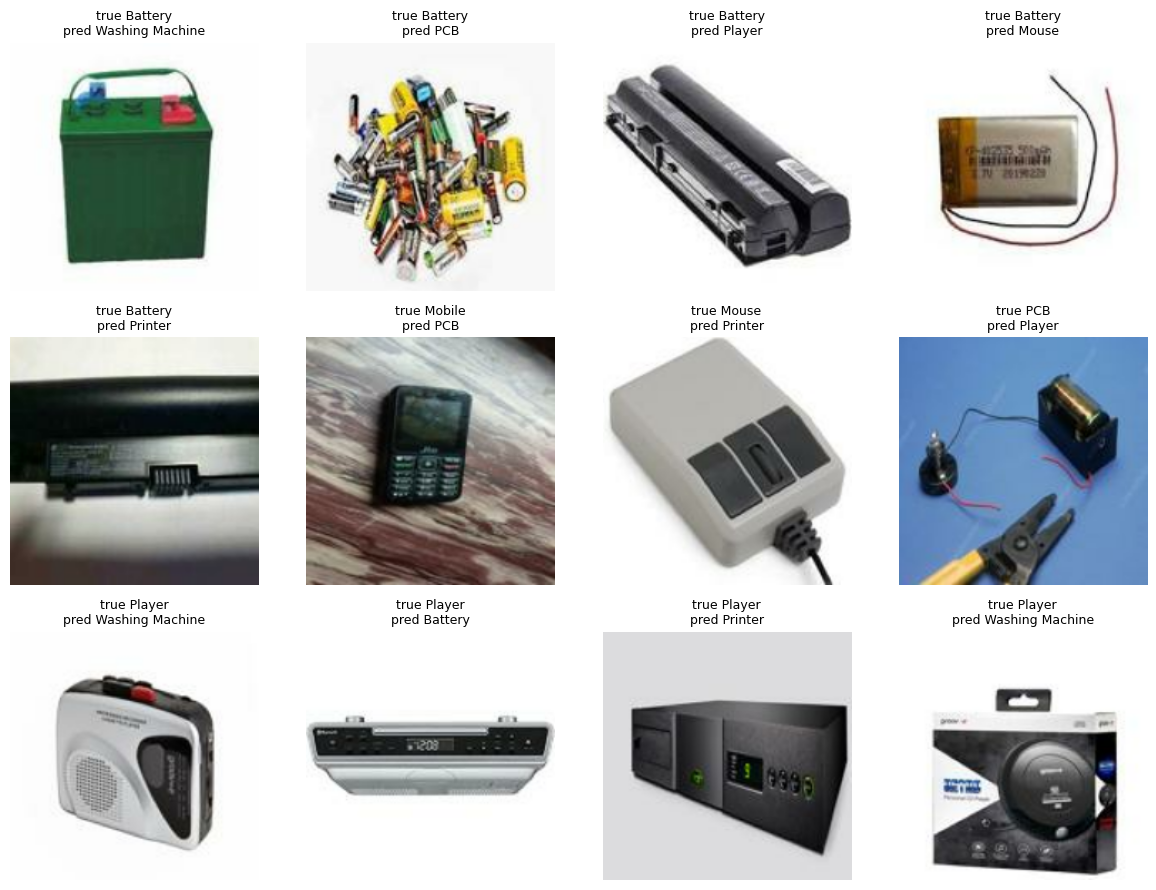

In [22]:
imgs  = np.concatenate([x.numpy() for x, _ in raw_test]).astype("uint8")
yt    = np.concatenate([y.numpy() for _, y in raw_test])
yp    = resnet.predict(te_r, verbose=0).argmax(1)
wrong = np.where(yt != yp)[0]
print(f"ResNet152 missed {len(wrong)}/{len(yt)} test images")

k = min(12, len(wrong))
rows = (k + 3) // 4
plt.figure(figsize=(12, 3 * rows))
for i, idx in enumerate(wrong[:k]):
    plt.subplot(rows, 4, i + 1); plt.imshow(imgs[idx]); plt.axis("off")
    plt.title(f"true {CLASS_NAMES[yt[idx]]}\npred {CLASS_NAMES[yp[idx]]}", fontsize=9)
plt.tight_layout(); plt.show()